# Quantum trajectories

Quantum trajectories are a powerful tool for simulating open quantum dynamics. The idea is simple: the Lindblad master equation
\begin{equation}
\partial_t \rho = -i[H,\rho] + \sum_m \gamma_m \left( L_m \rho L_m^\dagger - \frac{1}{2} \{L_m^\dagger L_m, \rho\}\right)
\end{equation}
generates a mixed state $\rho$, which can be thought as a statistical mixture of multiple pure states
\begin{equation}
\rho = \sum_j p_j |\psi_j\rangle\langle|\psi_j|.
\end{equation}
Instead of evaluating the dynamics of the density matrix, one can **unravel** the dynamics in a collection of stochastic pure quantum trajectories, and access ensemble-averaged properties as statistical averages.

The main advantage of this procedure is the reduction of the size of the state to be stored. For a Hilbert space of dimension $D$, pure states are arrays of $D$ elements, whereas density matrices contain $D^2$ elements.

We now illustrate some basic examples on how quantum trajectories can be used to simulate open-system evolution, starting from a simple single-qubit example. Consider the Lindblad master equation characterized by a Hamiltonian
\begin{equation}
H = \omega \sigma^x
\end{equation}
and a single jump operator
\begin{equation}
L = \sigma^+ = \frac{\sigma^x+i\sigma^y}{2},
\end{equation}
with a dissipation rate $\gamma$.

In [3]:
using LinearAlgebra
using CairoMakie

# Hamiltonian
omega = 1.0
H = omega * sigmax()

# Jump operator
L = sigmap()
gamma = 1.0

1.0

We implement the **quantum jump** unraveling of the master equation.

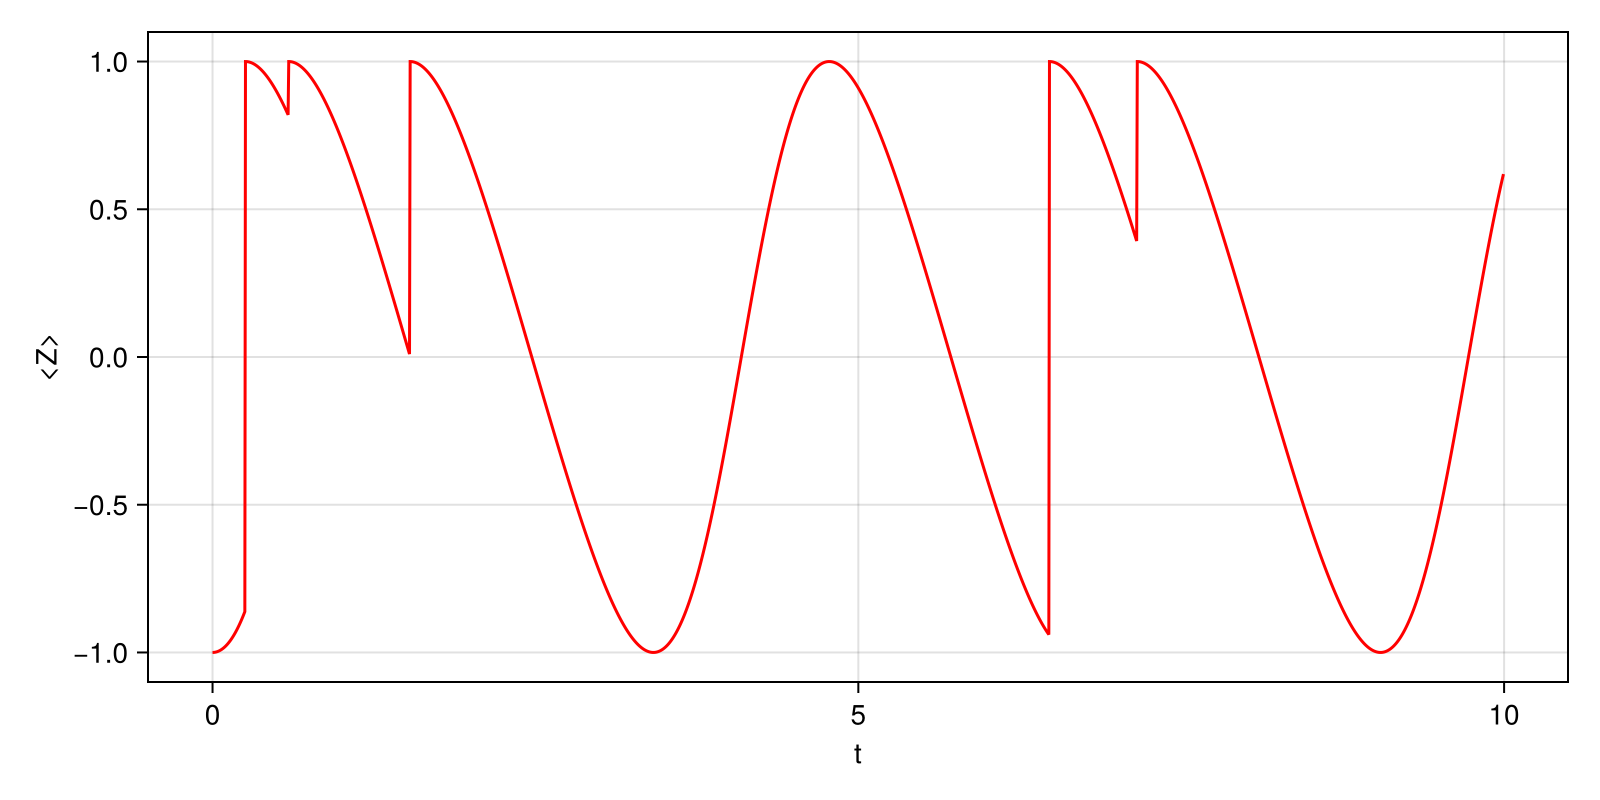

In [5]:
# Parameters

psi0 = ComplexF64[0, 1] # down state
dt = 0.005
ntsteps = 2000

# Effective Hamiltonian
Heff = H - 0.5im * gamma * L' * L

function jump_evolution(L, psi)
    # Perform a jump and renormalize the state
    psi_out = L * psi
    n = norm(psi_out)
    return psi_out/n
end

function quantum_jump_evolution(Heff, L, dt, ntsteps, psi0)
    # Use the method of arXiv:1405.6694, Sec. III.D
    Z_avg = zeros(Float64, ntsteps)

    U = exp(-im * Heff * dt)
    # Since this is a single qubit, we could actually evaluate U exactly, but
    # it's not possible in general.

    r = rand()
    n = 1.0

    psi = copy(psi0)

    for tt in 1:ntsteps
        Z_avg[tt] = real(psi' * sigmaz() * psi) / n^2

        psi = U * psi
        # If we have a many-body system, usually it's not possible to build U.
        # We can instead integrate numerically the (effective) Schrodinger eq.

        n = norm(psi)

        if n^2 < r
            psi = jump_evolution(L, psi)
            n = 1.0
            r = rand()
        end
    end

    return Z_avg
end

Z_traj = quantum_jump_evolution(Heff, L, dt, ntsteps, psi0)

t = (0:ntsteps-1) .* dt

fig = Figure(size = (800, 400))
ax = Axis(fig[1, 1],
    xlabel = "t",
    ylabel = "<Z>",
    xgridvisible = true,
    ygridvisible = true
)

lines!(ax, t, Z_traj, color = :red, linewidth = 1.5)

fig

Single quantum-jump trajectories feature sudden discontinuities. Indeed, the operator $L$ implements instantaneous jumps in the Hilbert space.

Now, let's generate many trajectories and track the average magnetization

In [7]:
sample = 5000

Z_qj = zeros(Float64, ntsteps)
Z2_qj = zeros(Float64, ntsteps)

for ss in 1:sample
    Z_traj = quantum_jump_evolution(Heff, L, dt, ntsteps, psi0)
    Z_qj .+= Z_traj ./ sample
    Z2_qj .+= (Z_traj .^ 2) ./ sample
end

sigma_Z_qj = sqrt.(Z2_qj .- Z_qj.^2 .+ 1e-10) ./ sqrt(sample);

Compare to the Lindblad evolution

In [1]:
using QuantumToolbox

result = mesolve(H, basis(2,1), t, [sqrt(gamma)*L]; e_ops=[sigmaz()])
Z_lind = real.(result.expect[1, :])

fig = Figure(size = (800, 400))
ax = Axis(fig[1, 1],
    xlabel = "t",
    ylabel = "<Z>",
    xgridvisible = true,
    ygridvisible = true
)

band!(ax, t, Z_qj .- sigma_Z_qj, Z_qj .+ sigma_Z_qj, color = (:red, 0.5))
lines!(ax, t, Z_qj, color = :red, label = "QJ average")
lines!(ax, t, Z_lind, color = :blue, linestyle = :dash, label = "Lindblad")
axislegend(ax, framevisible = false)

fig

LoadError: ArgumentError: Package QuantumToolbox not found in current path.
- Run `import Pkg; Pkg.add("QuantumToolbox")` to install the QuantumToolbox package.